# Семинар 6. Итеративные методы с гладкими и негладкими регуляризирующими штрафными функциями. Проксимальные алгоритмы и их развёртывание нейросетями.

<p><div class="lev1"><a href="#Введение"><span class="toc-item-num"></span>Введение</a></div>
<p><div class="lev1"><a href="#1.-Итеративные методы"><span class="toc-item-num"></span>1. Итеративные методы</a></div>
<p><div class="lev1"><a href="#2.-Регуляризация-Тихонова"><span class="toc-item-num"></span>2. Регуляризация Тихонова - простейший случай</a></div>
<p><div class="lev1"><a href="#3.-Проксимальные-методы-для-негладкой-регуляризации:-АDMM,-PGD,-Primal-dual splitting"><span class="toc-item-num"></span>
3. Проксимальные методы для негладкой регуляризации: АDMM, PGD, Primal-dual splitting Chambolle-Pock algorithm (TV-regularization)
</a></div>
<p><div class="lev1"><a href="#4.-Развёртывание итеративных методов при помощи нейросетей"><span class="toc-item-num"></span>
    4. Развёртывание итеративных методов при помощи нейросетей
</a></div>
<p><div class="lev1"><a href="#5. Регуляризация проксимальными методами на основе априорных данных"><span class="toc-item-num"></span>
5. Регуляризация проксимальными методами на основе априорных данных</a></div>
<p><div class="lev1"><a href="#Дополнительные материалы"><span class="toc-item-num"></span>5. Дополнительные материалы</a></div>


Минимум необходимых библиотек

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import tomopy # library for tomography methods / testing benchmark
import seaborn as sns
import numba as nb 
from numba import njit, prange, float32, float64

from tqdm import tqdm

In [241]:
# code for Radon projector

# ---------------------------------------------------------------------------------  
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 

@nb.njit(cache=True, parallel=False)
def siddon_line_projector(image, phi, shift, radius=1.0):
    """
        Sidon line projector - fast and exact execution algorithm
        for the ray transform along the line

        The code is not yet optimized - works not really fast 
    """
    
    c = np.cos(phi)
    s = np.sin(phi)
    R = radius
    sh = shift
    
    if (sh > R*np.sqrt(2)):
        return 0
    
    # get image size, pixel size
    npixels = image.shape[0]
    dx = 2*R / npixels # pixel's side length 
    
    # set the geometry of the line
    line_center = np.array([[sh * c], [sh * s]])
    direction = np.array([[-s], [c]])
    
    # 1. find intersections of the line with borders [-radius,radius]x[-radius, radius]
    n_intersect_pts = 0
    end_pts = np.zeros((2,2))
    
    # bottom border
    if (np.abs((sh + R*s)) < np.abs(c)*R):
        end_pts[n_intersect_pts, 0] = (sh + R*s)/c
        end_pts[n_intersect_pts, 1] = -R
        n_intersect_pts += 1 
        
    # right border
    if (np.abs((sh - R*c)) < np.abs(s)*R):
        end_pts[n_intersect_pts, 0] = R
        end_pts[n_intersect_pts, 1] = (sh - R*c)/s
        n_intersect_pts += 1 
            
            
    # top border
    if (np.abs((sh - R*s)) < np.abs(c)*R and n_intersect_pts < 2):
        end_pts[n_intersect_pts, 0] = (sh - R*s)/c
        end_pts[n_intersect_pts, 1] = R
        n_intersect_pts += 1 
            
    # left border
    if (np.abs((sh + R*c)) < np.abs(s)*R and n_intersect_pts < 2):
        end_pts[n_intersect_pts, 0] = -R
        end_pts[n_intersect_pts, 1] = (sh + R*c)/s
        n_intersect_pts += 1
            
    #assert (n_intersect_pts == 2), f"Failed to find 2 intersections. Line parameters: shift={sh}, phi={phi}, n_intersect={n_intersect_pts}"
    
    
    # check if points are not ordered according the direction - flip rows
    if (np.dot(end_pts[1, :] - end_pts[0, :], direction) < 0):
        tmp = end_pts[1].copy()
        end_pts[1] = end_pts[0]
        end_pts[0] = tmp
        #end_pts = np.flipud(end_pts, axis=0)
        #end_pts[[0, 1], :] = end_pts[[1, 0], :] 
    
        
    # 2.1 compute intersections x-axes
    x_max = np.max(end_pts[:, 0])
    x_min = np.min(end_pts[:, 0])
    dir_x = end_pts[1, 0] - end_pts[0, 0]
    
    x_axes = np.linspace(-R, R, npixels + 1)[1 : -1]
    x_coords_intersect = x_axes[(x_axes > x_min)*(x_axes < x_max)]
    x_pts_intersect = []
    for x in x_coords_intersect:
        alpha = (x - end_pts[0, 0])  / dir_x
        #assert ((alpha > 0.0) and (alpha < 1.0)), f"Failure to find intersection with line x={x}."
        y = end_pts[0, 1] * (1.0 - alpha) + end_pts[1, 1] * alpha
        x_pts_intersect.append([x, y, alpha]) 
    
    # 2.2 compute intersections y-axes
    y_max = np.max(end_pts[:, 1])
    y_min = np.min(end_pts[:, 1])
    dir_y = (end_pts[1, 1] - end_pts[0, 1])
    
    y_axes = np.linspace(-R, R, npixels + 1)[1 : -1]
    y_coords_intersect = y_axes[(y_axes > y_min)*(y_axes < y_max)]
    y_pts_intersect = []
    for y in y_coords_intersect:
        alpha = (y - end_pts[0, 1])  / dir_y
        #assert ((alpha > 0.0) & (alpha < 1.0))
        x = end_pts[0, 0] * (1.0 - alpha) + end_pts[1, 0] * alpha
        y_pts_intersect.append([x, y, alpha])
    
    # 3. merge ordered arrays of intersection points into one array of ordered intersections points
    #    increasing ordering ordering - column alpha
    
    # order both arrays x_pts_intersect, y_pts_intersect in increasing length with order
    if ((end_pts[1, 0] - end_pts[0, 0]) < 0.0):
        x_pts_intersect.reverse()
        
    if ((end_pts[1, 1] - end_pts[0, 1]) < 0.0):
        y_pts_intersect.reverse()
    
    len_x_intersect = len(x_pts_intersect)
    len_y_intersect = len(y_pts_intersect)
    ind_x = 0
    ind_y = 0
    pts_intersect = []
    
    # Numba feature (list.insert is not implemented in Numba yet)
    pts_intersect.append([end_pts[0, 0], end_pts[0, 1],  0])
    
    
    while (ind_x < len_x_intersect and ind_y < len_y_intersect):
            
        if (x_pts_intersect[ind_x][-1] < y_pts_intersect[ind_y][-1]):
            pts_intersect.append(x_pts_intersect[ind_x])
            ind_x += 1
            continue
            
        if (x_pts_intersect[ind_x][-1] > y_pts_intersect[ind_y][-1]):
            pts_intersect.append(y_pts_intersect[ind_y])
            ind_y += 1
            continue
                
        if (x_pts_intersect[ind_x][-1] == y_pts_intersect[ind_y][-1]):
            pts_intersect.append(x_pts_intersect[ind_x])
            ind_x += 1
            ind_y += 1
            # continue 

    if (ind_x == len_x_intersect):
            
            assert ind_y < len_y_intersect, "Failed to attach the rest of ordered y-array"
            
            for ind in range(ind_y, len_y_intersect):
                pts_intersect.append(y_pts_intersect[ind])
            
    if (ind_y == len_y_intersect):
            assert ind_x < len_x_intersect, "Failed to attach the rest of ordered x-array"
            
            for ind in range(ind_x, len_x_intersect):
                pts_intersect.append(x_pts_intersect[ind])
                
            
    # add last point
    pts_intersect.append([end_pts[1, 0], end_pts[1, 1],  1])
    
    
    # 4. compute the value of the line integral
    ray_int_value = 0.0
    len_intersection = np.linalg.norm(end_pts[0] - end_pts[1])
    
    for ind in range(len(pts_intersect)-1):
        pix_len = (pts_intersect[ind + 1][2] - pts_intersect[ind][2])
        
        # get indicies of middle points
        mid_x = (pts_intersect[ind + 1][0] + pts_intersect[ind][0]) * 0.5
        mid_y = (pts_intersect[ind + 1][1] + pts_intersect[ind][1]) * 0.5        
        ind_x = int((mid_x + R) / dx) 
        ind_y = npixels - 1 - int((mid_y + R) / dx)
        
        im_val = 0.0
        if (ind_x >= 0 and ind_x < npixels and ind_y >= 0 and ind_y < npixels):
            im_val = image[ind_y, ind_x]
        
        ray_int_value += pix_len * im_val
        
    # computation is over
    return ray_int_value * len_intersection



# ---------------------------------------------------------------------------------  
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 

@nb.njit(parallel=True)
def radon2d_siddon(image, ntheta, nshift, radius=1.0):
    
    # image size
    npixels = image.shape[0]
    dx = 2.0*radius / npixels
    shifts = np.linspace(-radius + dx/2, radius-dx/2, nshift)
    theta = np.linspace(0, 2*np.pi-2*np.pi/ntheta, ntheta)
    
    # compute projections 
    proj = np.zeros((ntheta, nshift))
    for i_theta in range(ntheta):
        for i_shift in range(nshift):
            proj[i_theta][i_shift] = siddon_line_projector(image, theta[i_theta], 
                                                          shifts[i_shift], radius)    
    return proj

# ---------------------------------------------------------------------------------  
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 
# --------------------------------------------------------------------------------- 

def matrixradon2d_siddon(npixels, ntheta, nshift, radius=1.0):
        
    # Radon matrix
    radon_matrix = np.zeros((ntheta*nshift, npixels**2))
        
    # init geometry/sizes
    dx = 2.0*radius / npixels # pixel's sidelength
    shifts = np.linspace(-radius + dx/2, radius-dx/2, nshift)
    theta = np.linspace(0, 2*np.pi, ntheta, endpoint = False)
    
    for i_pixel in range(npixels**2):
        
        # pixel's coordinates
        pixel_coords = np.array([-radius + dx/2 + dx*(i_pixel % npixels),  
                                  radius - dx/2 - dx*(i_pixel // npixels)])
        
        # create one-pixel image 
        image = np.zeros(npixels**2)
        image[i_pixel] = 1.0
        image = np.reshape(image, (npixels, npixels))
    
        # compute matrix projection vector 
        proj_vector = np.zeros((ntheta, nshift))
        
        for i_theta in range(ntheta):
            
            # find shifts that are needed for computation for the pixel
            phi = theta[i_theta]
            normal = np.array([np.cos(phi), np.sin(phi)])
            pixel_shift = np.dot(pixel_coords, normal)
            
            supp_ind = (np.arange(nshift))[(np.fabs(shifts - pixel_shift) < dx*np.sqrt(2))]
            
            for i_shift in supp_ind:
                proj_vector[i_theta, i_shift] = siddon_line_projector(image, theta[i_theta], 
                                                          shifts[i_shift], radius)
        # return column
        radon_matrix[:, i_pixel] = np.reshape(proj_vector, ntheta*nshift)
        
    # return complete matrix
    return radon_matrix



### Введение

В данном семинаре мы рассмотрим итеративные методы восстановлений, которые 
являются удобной альтернативой аналитическим методам из предыдущих заданий. 

В целом, итеративные методы привлекательны потому что

 1. просты в моделировании (особенно удобны когда задача не имеет удобной аналитической формы)
 
 
 2. гибкие, потому что относительно легко позволяют использовать априорную информацию
 
 
 3. (очень часто) масштабируемы на большие размерности 
 
В то же время 

 1. скорость сходимости метода может быть очень низкой (тут полезно как раз знать теорию, 
    чтобы понимать что влияет на их скорость)
    
    
 2. требуют калибровки гиперпараметров (плата за использование информативной априорной информации)
 
 3. требуют существенных вычислительных ресурсов (к сожалению об интересных вычислениях на ваших карманных часах 
    можно забыть, даже если вы можете полностью переписать ядро вашей ОС)
 
 
В данном семинаре мы посмотрим на следующие методы решения обратных задач

 1. градиентный спуск для регуляризации Тихонова
 2. проксимальные методы - ADMM, PGD, Chambolle-Pock Primal-Dual splitting для $L^1$ и $TV$-регуляризаций
 3. развёртвыние методов из пункта (2) при помощи нейросетей - ускорение
 4. регуляризация на основе данных - Gaussian/Bregman Denoisers
 
Данные методы мы применим к обратным задачам следующих видов

 * image deblurring - деконволюция сглаживающего фильтра 
 * image inpainting - восстановление изображения скрытого за бинарной маской
 * inverse tomography problem - преобразование Радона с Пуассоновским шумом (малой размерности)
 
 
Во всех случаях мы будем применять методы восстановлений к изображениям. 

Тем не менее, данные подходы 
применимы и к задачам без изображений: регрессия, сглаживание одномерных сигналов, 
интерполяция и прочие. 

###  Экспериментальная установка

Загрузим исходные изображения для трёх экспериментов и сгенерируем данные по которым 
будут проводится восстановления

In [88]:
import skimage.data as skdata 

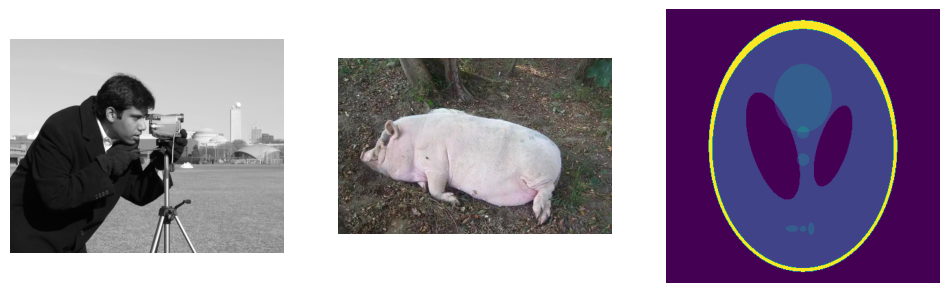

(512, 512) (400, 400) (400, 400)


In [244]:
camera_phantom = skdata.camera().astype(float)/255. # camera phantom
pig_phantom = plt.imread('pig.jpg', format='jpg') # pig phantom
shepp_logan_phantom = skdata.shepp_logan_phantom() # Shepp-Logan phantom (for tomo)

fig, axs = plt.subplots(1, 3, figsize=(12, 8), sharey=True)
axs[0].imshow(camera_phantom, cmap='gray')
axs[0].axis('off')
axs[1].imshow(pig_phantom)
axs[1].axis('off')
axs[2].imshow(shepp_logan_phantom)
axs[2].axis('off')
plt.show()
print(camera_phantom.shape, shepp_logan_phantom.shape, shepp_logan_phantom.shape)

Уменьшим размер изображений, чтобы облегчить последующие вычисления

In [90]:
import skimage.transform

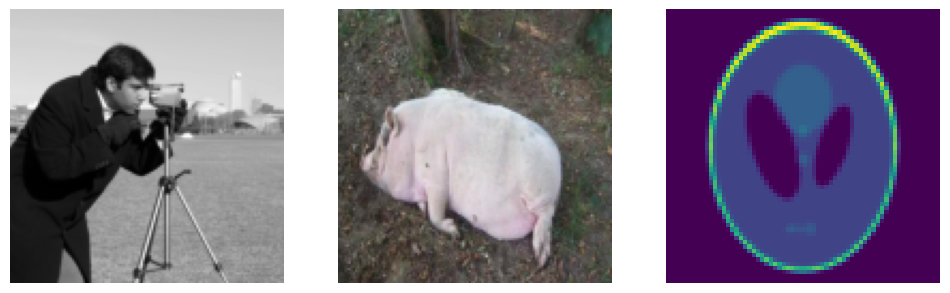

(128, 128) (128, 128, 3) (64, 64)


In [243]:
camera_phantom = skimage.transform.resize(camera_phantom, (128,128))
pig_phantom = skimage.transform.resize(pig_phantom, (128,128))
shepp_logan_phantom = skimage.transform.resize(shepp_logan_phantom, (64, 64))

fig, axs = plt.subplots(1, 3, figsize=(12, 8), sharey=False)
axs[0].imshow(camera_phantom, cmap='gray')
axs[0].axis('off')
axs[1].imshow(pig_phantom)
axs[1].axis('off')
axs[2].imshow(shepp_logan_phantom)
axs[2].axis('off')
plt.show()

print(camera_phantom.shape, pig_phantom.shape, shepp_logan_phantom.shape)

Сгенерируем измеряемые данные:

 * человек с камерой - gaussian blur
 * свинья - impainting черного квадрата по центру
 * Shepp-Logan - преобразование Радона с генерацией пуассоновского шума

In [77]:
# application of blur / construction of blurring matrix

In [78]:
# inpainting

In [202]:
# radon transform / matrix construction

projector = matrixradon2d_siddon(64, 64, 64, 1.0) # doesn't work at all in python notebook

In [203]:
# sparse data 
sinogram = projector @ shepp_logan_phantom.reshape((-1, 1)) # shape (4096, 1)

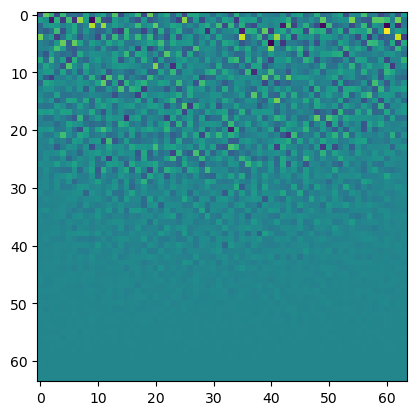

In [204]:
# standard nonregularized reconstruction
pseudo_recon = np.linalg.inv(projector.T @ projector) @ (projector.T @ sinogram)
plt.imshow(pseudo_recon.reshape((64,64)))
plt.show()

### Итеративные методы

### Проксимальные методы для негладкой регуляризации: АDMM, PGD, Primal-dual splitting

#### ADMM - Augmented Lagrangian method of multipliers

Расширенный метод множителей Лагранжа (Augmented Lagrangian method of multipliers - ADMM) включает в себя серию различных алгоритмов объединённых одной общей идеей, пояснить которую лучше всего путёв вывода алгоритма на одном из примеров (материал взят из [лекций](http://pages.cs.wisc.edu/~swright/nd2016/IMA_augmentedLagrangian.pdf)). 

**Пример:** Рассматривается задача с ограничением:

$$
    \text{minimize } f(x), \, Ax = b.
$$
Рассмотрим функцию Лагранжа

$$
    L(x, \mu) = f(x) + \mu^T(Ax-b).
$$
Отчасти, интерес использования $L(x,\mu)$ связан с тем, что исходная задача может быть переформулирована 
эквивалентным образом

$$
    \min_x \max_\mu L(x,\mu).
$$
Действительно, легко заметить, что оптимизируемый функционал равен $+\infty$, когда нарушено ограничение $Ax=b$.
Оптимизация функционала по $\mu$ в итоге даёт очень негладкую функцию для которой нет простой аналитической
формы. Основная идея заключается в том, чтобы "сгладить" функционал априорно оценив $\mu \approx \bar{\mu}$. 
Это можно сделать заменой исходной задачи на её амортизированную версию: 

$$
    \min_x \max_\mu \left(
        f(x) + \mu^T(Ax-b) -\dfrac{1}{2\rho}\|\mu - \bar{\mu}\|^2
    \right).
$$

Заметим, что знак минус связан с тем, что внутренняя задача связана с максимизацией. В такой постановке максимизация по $\mu$ становится совсем простой, для которой решение находится явно

$$
    \mu = \bar{\mu} + \rho(Ax-b). 
$$

Подставляя данное решение в исходный функционал с амортизацией получаем 

$$
    f(x) + \bar{\mu}^T(Ax-b) + \dfrac{\rho}{2}\|Ax-b\|^2.
$$
Вышеприведённый функционал называется расширенным Лагранжианом (расширение путём добавления квадратичного члена - отсюда и название метода). Функционал теперь мы можем минимизировать по $x$ без ограничений, тем более, что добавленный квадратичный член увеличивает выпуклость функционала, что облегчает задачу на практике. Найдя решение $x'$, можно обновить $\bar{\mu}$ до $\bar{\mu}'$

$$
    \bar{\mu}' = \mu + \rho(Ax'-b),
$$
обновив после этого $x$ и так далее. То есть на каждом шаге мы обновляем априорную информацию о $\mu$ и согласно ей обновляем текущий вектор решений:

  1. $x_{k} = \arg \min_x L(x,\mu_{k-1}; \rho)$
  2. $\mu_k = \arg \min_\mu L(x_k, \mu; \rho)$
  
Известно, что если $f$-выпуклая и непрерывная, данный метод сходится к решению (если оно существует). 

**Заключение:** данный вывод заключает в себе лишь основную идею, стоящую за ADMM (разумеется есть и другие интерпретации). Используя данную аналогию можно расширить использование данного метода на широкий класс релевантных задач. Также можно заметить, эффект константы $\rho$ -- она влияет скорость обновления $\mu$: 
маленькое значение $\rho$ означает слабое изменение $\mu$ и соответственно меньшую скорость сходимости, 
с другой стороны оно слабее регуляризирует промежуточный шаг с обновлением $x$ (в некоторых задачах этот 
шаг может быть весьма трудоёмким). В целом выбор $\rho$ подбирается методом "проб и ошибок", если нет 
существенной априорной информации о функционале $f$.

**Задача с негладкой регуляризацией:** При анализе изображений довольно часто релевантным оказыватся предположение, что искомый вектор (изображение) является разреженным. В таких случаях часто используют штрафную функцию в виде $L^1$-нормы (если её аналог можно определить в данном контексте), которая не является дифференцируемой. Данную ситуацию можно обобщить на негладкую штрафную функцию $g$ общего вида

$$
    \text{minimize}_x \, f(x) + \lambda g(x). 
$$
Данная задча эквивалентна следующей
$$
    \text{minimize}_{(x,z)}\, f(x)  + \lambda g(z), \, x = z.
$$

К задаче данного вида можно применить ADMM, так как это было сделано выше. В итоге получим схему 
  1. $(x_k,z_k) = \arg\min_{(x,z)}\left( f(x) + \lambda g(z) + \mu_{k-1}^T(x-z) + \dfrac{\rho}{2}\|x-z\|^2\right)$
  2. $\mu_k = \mu_{k-1} + \rho(x_k-z_k)$.
  
Шаг 1 можно разделить на два, используя координатный спуск

  1. $x_k = \arg\min_x \left( f(x) + \mu_{k-1}^T(x-z_{k-1}) + \dfrac{\rho}{2}\|x-z_{k-1}\|^2\right)$
  2. $z_k = \arg\min_z \left( \lambda g(z) + \mu_{k-1}^T(x_k-z) + \dfrac{\rho}{2}\|x_k-z\|^2\right)$
  3. $\mu_k = \mu_{k-1} + \rho(x_k-z_k)$.
  

**Задача 1.** Рассмотрим применение ADMM к задаче томографии с $L^1$-регуляризацией (LASSO)

Будем рассматривать задачу вида
$$
    \dfrac{1}{2}\|Rx-y\|^2 + \lambda \|x\|_1.
$$

Тогда итерации будут выглядеть следующим образом:

 1. $x_k = (R^TR + I\rho)^{-1}(R^Ty - \mu_{k-1} + \rho z_{k-1})$
 2. $z_{k,i} = \max(0, x_{k,i} + \frac{\mu_{k-1,i}}{\rho} - \frac{\lambda}{\rho}) + \min(0, x_{k,i} + \frac{\mu_{k-1,i}}{\rho} + \frac{\lambda}{\rho})$ (shrinkage map)
 3. $\mu_k = \mu_{k-1} + \rho(x_k - z_k)$.
 
Имплементируйте данную итеративную схему и добейтесь наилучшего восстановления, подбирая параметры $\rho$, $\lambda$. Что вы можете сказать об их влиянии на скорость сходимости и на само решение?

In [229]:
# implementation for the objective functional
def objective_lasso(x, y, projector, l):
    return 0.5*np.linalg.norm(projector @ x - y)**2 + l*np.linalg.norm(x, ord=1)

In [206]:
# implementation of ADMM for Radon transform
def admm_lasso_update_x(projector, rprojector_inv, m, z, r, data):
    """
    Description
        Update step for 'x' variable
        d - data dimension
        p - signal dimension
    Input 
        projector : ndarray of shape (d, p)
        m : ndarray of shape (p, 1)
        z : ndarray of shape (p, 1)
        data : ndarray of shape (d, 1)
        proj_precomp_flag : 
    Output
        ndarray of shape (p, 1)
    """

    mat = rprojector_inv
    vec = projector.T @ data - m + r*z
    
    return mat @ vec

def admm_lasso_update_z(x, m, l, r):
    """
    Description
        Update step for 'z' variable
        p - signal dimension
    Input
        x : ndarray of shape (p,1)
        m : ndarray of shape (p,1)
        l : positive scalar
        r : positive scalar
    Output 
        ndarray of shape (p, 1)
    """    
    shr_right = np.max(np.concatenate([np.zeros((x.shape[0],1)), x + m/r-l/r], axis=1), axis = 1, keepdims=True)
    shr_left = np.min(np.concatenate([np.zeros((x.shape[0],1)), x + m/r+l/r], axis=1), axis = 1, keepdims=True)
    
    return shr_right + shr_left

def admm_lasso_update_m(m, x, z, r):
    return m + r*(x-z)

In [245]:
def admm_lasso(projector, x, m, z, r, l, data, niter=1000, rel_tol = 1e-8):
    
    # preparation of containers
    curr_x = x
    curr_z = z
    curr_m = m
    hist = [curr_x]
    
    # precomputing regularized inverse 
    rprojector_inv = np.linalg.inv(projector.T @ projector + r*np.eye(z.shape[0]))
    
    for it in tqdm(range(niter)):
        # step x
        new_x = admm_lasso_update_x(projector, rprojector_inv, curr_m, curr_z, r, data)
        hist.append(new_x)
        if (np.linalg.norm(new_x-curr_x)/np.linalg.norm(curr_x) < rel_tol):
            print(f'ADMM-Lasso : early stop at iteration {it}')
            break
        curr_x = new_x
                
        # step z 
        new_z = admm_lasso_update_z(curr_x, curr_m, l, r)
        curr_z = new_z
            
        # step m 
        new_m = admm_lasso_update_m(curr_m, curr_x, curr_z, r)
        curr_m = new_m
        
    return hist, curr_x         

In [246]:
# reconstruction
x_init = np.ones((4096, 1))
m_init = np.ones((4096, 1))
z_init = np.ones((4096, 1))
r = 1e-1
l = 1e-7

hist, recon = admm_lasso(projector, x_init, m_init, z_init, r, l, sinogram, niter = 200)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 113.45it/s]


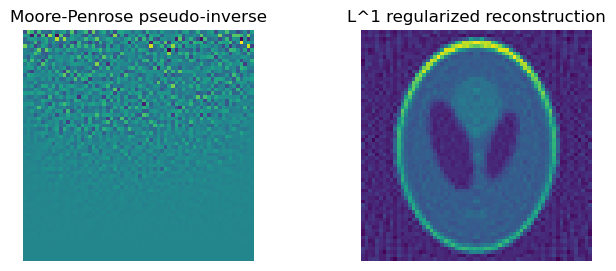

In [247]:
# plotting for single reconstruction

fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=False)

axs[0].imshow(pseudo_recon.reshape((64,64)))
axs[0].set_title('Moore-Penrose pseudo-inverse')
axs[0].axis('off')
axs[1].imshow(recon.reshape((64,64)))
axs[1].set_title('L^1 regularized reconstruction')
axs[1].axis('off')
plt.show()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 113.85it/s]


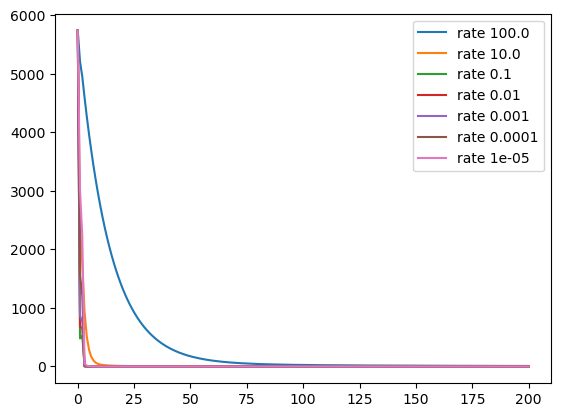

In [248]:
# calculation for the decay rate 

rates = [1e2, 1e1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
histories = []

for i,r in enumerate(rates): 
    hist, _ = admm_lasso(projector, x_init, m_init, z_init, r, l, sinogram, niter=200)
    histories.append(hist)
    hist_obj_vals = [objective_lasso(x, sinogram, projector, l) for x in hist]
    plt.plot(hist_obj_vals, label = 'rate ' + str(rates[i]))

plt.legend()
plt.show()

**Ответ:** параметр регуляризации $\lambda$ в масштабе сильно влияет на итоговое решение, параметр $\rho$ контролирует скорость сходимости и при больших $\rho$ сходимость быстрая, при маленьких сходимость медленная. Ресурсоёмкость алгоритма сильно зависит от функционала $f$ и от того, насколько тяжела соответствующая задача оптимизации (шаг обновления $x$). По факту, данный шаг можно заменить на шаг градиентного спуска и алгоритм также будет сходится, но медленней.

#### Проксимальный градиентный спуск (PGD - Proximal Gradient Descent)

Проксимальный градиентный спуск используется для решения той же задачи с негладкой регуляризацией:

$$
    \text{minimize }f(x) + \lambda g(x), 
$$
где $f$ - гладкая функция, а (регуляризация) негладкая. 

Основная идея алгоритма заключается в том, что $f$ локально аппроксимируется линейной функцией. Тогда 
правило обновления текущей точки $x$ можно записать как:

$$
    x_{k+1} = \arg\min_x \left(
        f(x_k) + \nabla f(x_k)^T(x-x_k) + \lambda g(x) + \dfrac{1}{2\delta}\|x-x_k\|^2
    \right).
$$

Квадратичный член необходим для регуляризации задачи. В частности, исключая члены, которые не зависят от $x$ получаем 

$$
    x_{k+1} = \arg\min_x \left(
        \lambda g(x) + \dfrac{1}{2\delta}\|x-(x_k - \delta \nabla f(x_k)\|^2
    \right) = \mathrm{Prox}_{\delta \lambda g}(x_k - \delta \nabla f(x_k)).
$$

Именно поэтому алгоритм называется *проксимальным*, так как новая точка соответствует проксимальному отображению 
градиентного шага по $f$.

**Задача 2.** Найдите проксимальное отображение для функции $g(x) = \|x\|_1$ и, используя его, имплементируйте PGD. Оцените скорость сходимости алгоритма, сравнив её с ADMM: сколько необходимо итераций каждому алгоритму, 
чтобы достичь приемлемого решения. Объясните почему количество итераций различается?

**Решение:** Проксимальное отображение по определению 
$$
    \mathrm{Prox}_{c\|\cdot\|_1}(y) = \arg\min_x c\|x\|_1 + \dfrac{1}{2}\|x-y\|^2. 
$$
Данная задача по минимизации состоит из $\dim x$ независимых одномерных задач, поэтому достаточно рассмотреть лишь 

$$
    \arg\min_{x\in R} c|x| + \dfrac{1}{2}(x-y)^2. 
$$

Достаточно легко показать, что решение данной задачи равняется

$$
    \hat{x} = \begin{cases}
        y - c, \, y > c, \\
        y + c, \, y < -c,
    \end{cases} \Rightarrow \hat{x} = \max(0, y-c) + \min(0, y + c)\, \text{(shrinkage map)}.
$$

Покоординатное применение данного отображения определяет проксимальный оператор для $L^1$-нормы в многомерном пространстве. Теперь имплементируем его: 

In [251]:
# PGD implementation

def grad_step(grad_map, x, s):
    """
    Description
        Gradient descent at point 'x' with rate 's'. 

    Input
        grad_map : callable(x)
        x : ndarray of shape (p, 1)
        s : scalar
    Output
        ndarray of shape (p,1)
    """
    return x-s*grad_map(x)

def prox_map_lasso(x, c):
    """
    Description
        Proximal map at 'x' for c|.|_1 regularizer. 
    
    Input
        x : ndarray of shape (p,1)
        s : positive scalar
    
    Output
        ndarray of shape (p,1)
    """
    shr_left = np.max(np.concatenate([np.zeros(x.shape), x-c], axis=1), axis=1, keepdims=True)
    shr_right = np.min(np.concatenate([np.zeros(x.shape), x+c], axis=1), axis=1, keepdims=True)
    
    return shr_left + shr_right

def pgd_lasso(grad_map, x, l, s, niter = 100, rel_tol = 1e-8):
    """
    Description
        Proximal gradient descent with l*|.|_1 regularizer.
    
    Input
        grad_map : callable(x)
        x : ndarray of shape (p,1)
        l : positive scalar
        s : positive scalar
    """
    # container initialization
    curr_x = x
    hist = [x]
    
    # main loop
    for it in tqdm(range(niter)):
        g = grad_step(grad_map, curr_x, s)
        p = prox_map_lasso(g, l*s)
        if (np.linalg.norm(curr_x - p)/np.linalg.norm(curr_x) < rel_tol):
            print(f'PGD-Lasso : early stop at iteration {it}')
            break
            
        curr_x = p
        hist.append(curr_x)
    
    return hist, curr_x

In [273]:
x_init = np.ones((4096,1))
l = 1e-7
s = 1e-1

hist, curr_x = pgd_lasso(lambda x: projector.T @ (projector @ x - sinogram), x_init, l, s, niter=100)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 96.99it/s]


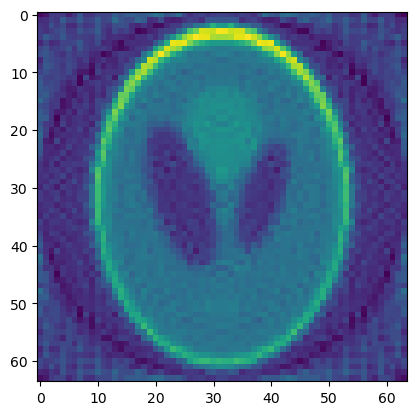

In [274]:
plt.imshow(curr_x.reshape((64, 64)))
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 82.01it/s]


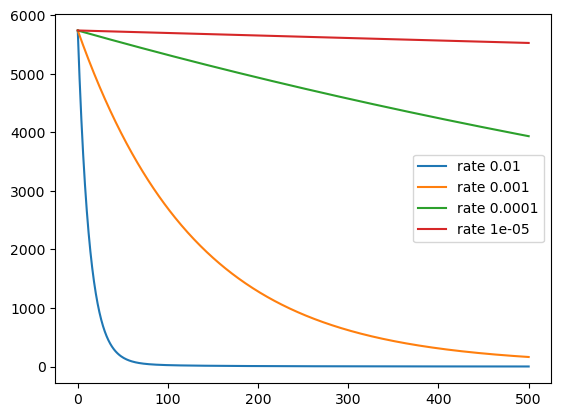

In [276]:
# calculation for different decay rates 

rates = [1e-2, 1e-3, 1e-4, 1e-5]
histories = []

for i,r in enumerate(rates): 
    hist, _ = pgd_lasso(lambda x: projector.T @ (projector @ x - sinogram), x_init, l, r, niter=500)
    histories.append(hist)
    hist_obj_vals = [objective_lasso(x, sinogram, projector, l) for x in hist]
    plt.plot(hist_obj_vals, label = 'rate ' + str(rates[i]))

plt.legend()
plt.show()

**Ответ:** в отличие от метода ADMM, где каждая из подзадач имеет точное решение, алгоритм PGD как алгоритм первого порядка, вообще говоря, может и разойтись при достаточно больших $s$. В целом, видно, что 200 итераций не хватает для полной сходимости, хотя для ADMM этого хватало вполне. Это неудивительно, ведь в нашей реализации ADMM - метод второго порядка, поэтому сходится быстрее. 

In [5]:
%magic